# Contents
This script parses the Raman results of the 10slm and 20slm measurements at 120mbar (10.1021/acsenergylett.1c01206). It then fits the mass flux profiles to the conservation of mass and energy, and saves the results in `output/data` for use in other notebooks. It also creates some plots in `output/media` which are used in the paper. 

# Instructions
1. Change `flowrate` (10 or 20), `upstream` (True or False).
2. Run all cells.
3. Repeat for all combinations of `flowrate` and `upstream` (4 in total) to get all data for the paper.

In [1]:
# Variables
flowrate = 20 # [slm] 10 or 20
upstream = True # True to look at z=-40mm (upstream), False z=20mm (downstream)
force_edge_300K = True # True to force the edge of the measurement to be 300K CO2, False to extrapolate the measurements

# Constants
pressure = 120
power = 1000 # [W]

In [2]:
import toddler
import os
import wedme
from pathlib import Path
import toddler.chemistry.cantera2 as ct2
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cantera as ct

wedme.apply.dev()
wedme.apply.slide_hw_hh()

dir_root = Path(os.getcwd())

dir_data = dir_root / "data" # Storage of the Raman input data (i.e. temperature and species concentrations)
dir_out = dir_root / "output" # Storage of the output of this work: flow profiles and fitted parameters
dir_media = dir_out / "media" # Storage of generated media (e.g. plots)
dir_output_data = dir_out / "data" # Storage of generated data (e.g. flow profiles)

dir_media.mkdir(exist_ok=True, parents=True)
dir_output_data.mkdir(exist_ok=True, parents=True)

assert dir_data.exists(), f"Data directory {dir_data} does not exist. Is this Jupyter notebook run from the correct location?"

In [3]:
def parse_files(path_meas, pattern_parse, pattern_filter):
    A = np.zeros((0, 12))

    x0 = 4 # [mm]
    dx_fiber_spacing = -2 # [mm]
    for i, (file, dx_measurement) in enumerate(toddler.files.filenames.glob(path_meas, pattern_filter, pattern_parse)):
        Ai = np.loadtxt(file)

        # Calculate correct axial position
        Ai[:, 1] = Ai[:, 1] * dx_fiber_spacing + x0 + dx_measurement

        A = np.append(A, Ai, axis=0)

    A[:, 2] *= 300 # convert to Kelvin
    A = A[np.lexsort((A[:,0], A[:,1]))] # Sort by radial and axial position
    return A

In [4]:
if upstream:
    z0 = -40
    power_fraction=1e-3
else:
    z0 = 20
    power_fraction=1

path_meas = dir_data / 'Forward Vortex Raman' / 'Results' / f"{flowrate:.0f} slm"

mass_CO2 = 44 # [amu]
massflow_total_input = toddler.physics.flow.slm_to_massflux(flowrate, mass_CO2) # [kg/s]
massflux_av = massflow_total_input / (np.pi*13e-3**2) # [kg/m^2/s]
SEI = power / massflow_total_input

pattern_filter = f"results_{pressure:d}_{flowrate:d}_*.txt"
pattern_parse = r'_([\-\d]+)_fin'
results = parse_files(path_meas, pattern_parse, pattern_filter)

meas_title = fr"FV {flowrate}slm $\mathrm{{CO_2}}$, {pressure}mbar, 1000W"
meas_filename = fr"fv_{flowrate}slm_CO2_{pressure}mbar_1000W"

In [5]:
from scipy.interpolate import RegularGridInterpolator

def interp(r, z, data, R_interp, Z_interp):
    interpfun = RegularGridInterpolator((r, z), data, method='linear',bounds_error=True, fill_value=np.nan)
    return interpfun((R_interp, Z_interp))

def interpolate_measurements(results, force_edge=False):
    z_meas = np.unique(results[:,1])
    r_meas = np.unique(results[:,0])
    T_meas = results[:,2].reshape((z_meas.size, r_meas.size))
    CO2_meas = results[:,3].reshape((z_meas.size, r_meas.size))
    CO_meas = results[:,4].reshape((z_meas.size, r_meas.size))
    O2_meas = results[:,5].reshape((z_meas.size, r_meas.size))
    O_meas = results[:,6].reshape((z_meas.size, r_meas.size))

    if force_edge:
        # Force edge temperature to be 300K, and edge concentration to be 100% CO2
        r_meas = np.append(r_meas, 13)
        T_meas = np.append(T_meas, np.ones((z_meas.size, 1))*300, axis=1)
        CO2_meas = np.append(CO2_meas, np.ones((z_meas.size, 1)), axis=1)
        CO_meas = np.append(CO_meas, np.zeros((z_meas.size, 1)), axis=1)
        O2_meas = np.append(O2_meas, np.zeros((z_meas.size, 1)), axis=1)
        O_meas = np.append(O_meas, np.zeros((z_meas.size, 1)), axis=1)

    z_interp = np.linspace(np.min(z_meas), np.max(z_meas), 1000)
    r_interp = np.linspace(np.min(r_meas), np.max(r_meas), 200)
    Z, R = np.meshgrid(z_interp, r_interp)
    dr = r_interp[1] - r_interp[0]

    T_interp = interp(r_meas, z_meas, T_meas.T, R, Z)
    CO2_interp = interp(r_meas, z_meas, CO2_meas.T, R, Z)
    CO_interp = interp(r_meas, z_meas, CO_meas.T, R, Z)
    O2_interp = interp(r_meas, z_meas, O2_meas.T, R, Z)
    O_interp = interp(r_meas, z_meas, O_meas.T, R, Z)

    return dr, r_interp, z_interp, R, Z, T_interp, CO2_interp, CO_interp, O2_interp, O_interp


dr, r_interp, z_interp, R, Z, T_interp, CO2_interp, CO_interp, O2_interp, O_interp = interpolate_measurements(results, force_edge_300K)

# Figure 2.

/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_46702/3034984015.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(dir_out / "media" / f"{meas_filename}_results_raman.pdf")
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
/Users/martijn/Projects/study/UM/CO2-flow/CO2-flow-conservation-laws/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


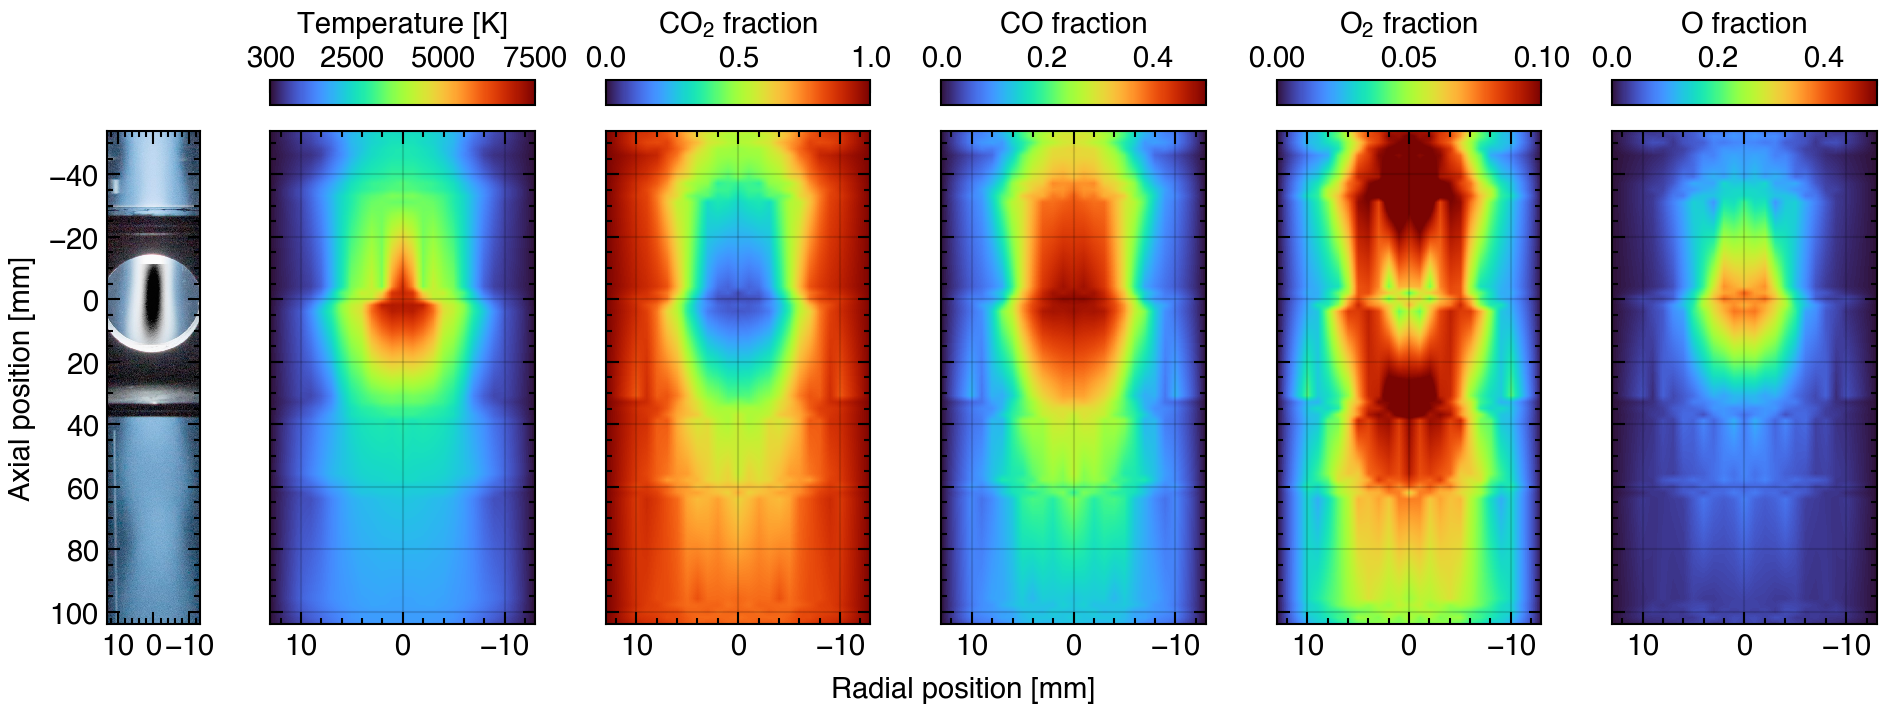

In [6]:
def my_imshow(ax, data, cmap='turbo', **kwargs):
    data_mirrored = np.concatenate([data[::-1, :], data], axis=0).T
    im = ax.imshow(data_mirrored, aspect='auto', cmap='turbo', extent=[np.max(r_interp), -np.max(r_interp), np.max(z_interp), np.min(z_interp)], **kwargs)
    ax.set_yticklabels([])
    ax.set_xlabel(None)
    # ax.grid(False)
    return im

def my_colorbar(im, ax, **kwargs):
    cbar = fig.colorbar(im, cax=ax, orientation='horizontal', **kwargs)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    return cbar

fig, axes = wedme.subplots.paper(2, 6, figsize=(wedme.PAPER_PH, wedme.PAPER_PW*0.5), height_ratios=[1,20], width_ratios=[0.35, 1, 1, 1, 1, 1], gridspec_kw={'bottom': 0.12})

import matplotlib.image as mpimg
img = mpimg.imread(path_meas.parent / f'CO_{flowrate:.0f}slm_{pressure:.0f}mbar_1000W.png')
imgplot = axes[1, 0].imshow(img[:-150, :], aspect='auto', extent=[np.max(r_interp), -np.max(r_interp), np.max(z_interp), np.min(z_interp)])

axes[1, 0].set_ylabel("Axial position [mm]")
axes[1, 0].set_xlabel(None)
axes[1, 0].grid(False)

im = my_imshow(axes[1, 1], T_interp, vmin=300, vmax=7500)
cbar_T = my_colorbar(im, axes[0, 1], label="Temperature [K]")
cbar_T.ax.set_xticks([300, 2500, 5000, 7500])

im = my_imshow(axes[1, 2], CO2_interp, vmin=0, vmax=1, cmap='Blues')
my_colorbar(im, axes[0, 2], label="CO$_2$ fraction")

im = my_imshow(axes[1, 3], CO_interp, vmin=0, vmax=0.5, cmap='Reds')
my_colorbar(im, axes[0, 3], label="CO fraction")

im = my_imshow(axes[1, 4], O2_interp, vmin=0, vmax=0.1, cmap='Reds')
my_colorbar(im, axes[0, 4], label="O$_2$ fraction")

im = my_imshow(axes[1, 5], O_interp, vmin=0, vmax=0.5, cmap='Reds')
my_colorbar(im, axes[0, 5], label="O fraction")

axes[0,0].axis('off')
# fig.subplots_adjust(bottom=0.05)
fig.supxlabel("Radial position [mm]", fontsize=axes[1,0].yaxis.label.get_size())
fig.subplots_adjust(wspace=0.3, hspace=0.1)

plt.savefig(dir_out / "media" / f"{meas_filename}_results_raman.pdf")
plt.show()

In [7]:
def calculate_thermodynamics(T, CO2, CO, O2, O, SEI):
    # Calculate the specific enthalpy, density and thermal conductivity at each point
    compositions = {
        "CO2": CO2,
        "CO": CO,
        "O2": O2,
        "O": O
    }
    specific_enthalpy,Tq,specific_density, thermal_conductivity = ct2.calculate_parameters(ct2.get_solution("CO2", "CO", "O2", "O"), compositions, pressure, T,\
                                                 specific_enthalpy = lambda x: x.enthalpy_mass, # [J/kg]
                                                 T = lambda x: x.T, # [K]
                                                 specific_density = lambda x: x.density_mass, # [kg/m3]
                                                 thermal_conductivity = lambda x: x.thermal_conductivity, # [W/m/K]
                                                 )
    
    specific_enthalpy -= ct2.calculate_parameters(ct2.get_solution("CO2", "CO", "O2", "O"), {"CO2": 1}, pressure, 300, specific_enthalpy = lambda x: x.enthalpy_mass)

    # The relative enthalpy is the key dimensionless parameter from which we can derive cumulative massflows.
    # See the secondary y-axes of figures 4 and 6.
    relative_enthalpy = specific_enthalpy / SEI
    
    return specific_enthalpy, specific_density, relative_enthalpy, thermal_conductivity


specific_enthalpy, specific_density, relative_enthalpy, thermal_conductivity = calculate_thermodynamics(T_interp, CO2_interp, CO_interp, O2_interp, O_interp, SEI)

# Diffusive heat loss (S1.2)
No figure in the paper, just a scalar estimation of heat loss.

In [8]:
# Get the index of the axial position closest to z0
idz = np.argmin(np.abs(z_interp - z0))
gas = ct.Solution("gri30_highT.yaml")

phiqdiff = np.zeros_like(r_interp)

# Smooth the species concentrations and temperature to get more accurate gradients, and calculate the gradients in the axial direction
dCO2dz = np.diff(scipy.ndimage.gaussian_filter1d(CO2_interp, sigma=10), axis=1) / np.diff(z_interp*1e-3)[0]
dCOdz = np.diff(scipy.ndimage.gaussian_filter1d(CO_interp, sigma=10), axis=1) / np.diff(z_interp*1e-3)[0]
dO2dz = np.diff(scipy.ndimage.gaussian_filter1d(O2_interp, sigma=10), axis=1) / np.diff(z_interp*1e-3)[0]
dOdz = np.diff(scipy.ndimage.gaussian_filter1d(O_interp, sigma=10), axis=1) / np.diff(z_interp*1e-3)[0]

# Calculate the binary diffusion coefficients for each combination of species at each point
id_CO2 = gas.species_index("CO2")
id_CO = gas.species_index("CO")
id_O2 = gas.species_index("O2")
id_O = gas.species_index("O")

for i, ri in enumerate(r_interp):
    localcomp = {
        "CO2": CO2_interp[i, idz],
        "CO": CO_interp[i, idz],
        "O2": O2_interp[i, idz],
        "O": O_interp[i, idz]
    }

    Ti = T_interp[i, idz]
    gas.TPX = Ti, pressure*100, {"CO2": 1}
    h_CO2 = gas.enthalpy_mole / 1e3
    gas.TPX = Ti, pressure*100, {"CO": 1}
    h_CO = gas.enthalpy_mole / 1e3
    gas.TPX = Ti, pressure*100, {"O2": 1}
    h_O2 = gas.enthalpy_mole / 1e3
    gas.TPX = Ti, pressure*100, {"O": 1}
    h_O = gas.enthalpy_mole / 1e3 # [J/mol]

    gas.TPX = Ti, pressure*100, localcomp
    Dij = gas.binary_diff_coeffs # [m2/s]

    D_CO2_O2 = Dij[id_CO2, id_O2] # [m2/s]
    D_CO2_O = Dij[id_CO2, id_O]
    D_CO2_CO = Dij[id_CO2, id_CO]

    D_CO_CO2 = Dij[id_CO, id_CO2]
    D_CO_O2 = Dij[id_CO, id_O2]
    D_CO_O = Dij[id_CO, id_O]
    
    D_O2_CO2 = Dij[id_O2, id_CO2]
    D_O2_CO = Dij[id_O2, id_CO]
    D_O2_O = Dij[id_O2, id_O]

    D_O_CO2 = Dij[id_O, id_CO2]
    D_O_CO = Dij[id_O, id_CO]
    D_O_O2 = Dij[id_O, id_O2]

    # Calculate the diffusive mass flux
    phi_CO2 = D_CO2_CO * localcomp["CO"] + D_CO2_O2 * localcomp["O2"] + D_CO2_O * localcomp["O"]
    phi_CO = D_CO_CO2 * localcomp["CO2"] + D_CO_O2 * localcomp["O2"] + D_CO_O * localcomp["O"]
    phi_O2 = D_O2_CO2 * localcomp["CO2"] + D_O2_CO * localcomp["CO"] + D_O2_O * localcomp["O"]
    phi_O = D_O_CO2 * localcomp["CO2"] + D_O_CO * localcomp["CO"] + D_O_O2 * localcomp["O2"]

    phiqdiff[i] = (phi_CO2 * dCO2dz[i, idz] * h_CO2 + \
                    phi_CO * dCOdz[i, idz] * h_CO + \
                    phi_O2 * dO2dz[i, idz] * h_O2 + \
                    phi_O * dOdz[i, idz] * h_O) * gas.density_mole * 1e3

# Integrate over the radius to get the total heat flux at z=z0
Q = np.sum(phiqdiff * 2 * np.pi * (r_interp * 1e-3) * (np.diff(r_interp)[0] * 1e-3)) # [J/s]
print(f"Diffusive heat loss: {Q:.1f} W")

Diffusive heat loss: 1.7 W


# Conductive heat loss (S1.1)

In [9]:
# Calculate axial temperature gradient
dTdz = np.diff(scipy.ndimage.gaussian_filter(T_interp, sigma=10), axis=1) / (np.diff(z_interp)[0]*1e-3) # [K/m]

# Calculate axial conductive heat flux
heatflux = thermal_conductivity[:, :-1] * dTdz # [W/m2]

# Integrate over the radius to get the total conductive heat flux at every z
heatflow = np.sum(heatflux * 2*np.pi*r_interp[:, np.newaxis]*1e-3 * (np.diff(r_interp*1e-3)[0]), axis=0) # [W]

# Find the conductive heat loss at z=z0
idz0 = np.argmin(np.abs(z_interp - z0))

print(f"Conductive heat loss at z={z0:.0f} mm: {abs(heatflow[idz0]):.1f} W")

Conductive heat loss at z=-40 mm: 2.2 W


In [10]:
def slice_to(z, z0, *args):
    idz0 = np.argmin(np.abs(z - z0))
    return [x[:, idz0] for x in args]

r_sim = r_interp
T_sim, relative_enthalpy_sim, specific_density_sim, specific_enthalpy_sim, CO2_sim, CO_sim, O2_sim, O_sim = slice_to(z_interp, z0, T_interp, relative_enthalpy, specific_density, specific_enthalpy, CO2_interp, CO_interp, O2_interp, O_interp)

def extend_to_r(r, R, dr, fillvalue, *args):
    r_append = np.arange(np.max(r_interp), 13, dr)[1:]
    r_new = np.concatenate((r, r_append))

    if fillvalue == 'extrapolate':
        return r_new, *[np.concatenate((x, scipy.interpolate.interp1d(r, x, fill_value="extrapolate")(r_append))) for x in args]
    else:
        return r_new, *[np.concatenate((x, np.ones(r_append.size) * fillvalue)) for x in args]

if not force_edge_300K:
    r_sim, T_sim, relative_enthalpy_sim, specific_density_sim, specific_enthalpy_sim = extend_to_r(r_sim, 13e-3, dr, 'extrapolate', T_sim, relative_enthalpy_sim, specific_density_sim, specific_enthalpy_sim)

# Clip impossible values at the extrapolated edges
specific_density_sim[specific_density_sim < 0] = 0
specific_enthalpy_sim[specific_enthalpy_sim < 0] = 0
relative_enthalpy_sim[relative_enthalpy_sim < 0] = 0
T_sim[T_sim < 300] = 300

In [11]:
from lmfit import Parameters, minimize, fit_report


A = np.pi * 13e-3**2 

def get_massflux(r, massflux_func, pars):
    massflux_norm = massflux_func(r, *[x.value for x in pars.values() if not x.name.startswith('_')])

    return massflux_norm

# This function is used to evaluate the residuals of the conservation of mass and heat for a given mass flux profile.
def conservation_mass_heat_residuals(pars, r, massflux_func, relative_enthalpy, rho, weight_massflux=1):
    # Calculate dr, making sure it has the same size as r
    dr = np.diff(r, append=np.nan)
    dr[-1] = dr[-2]

    # Calculate the cross-sectional area
    dA = 2 * r * dr

    # Calculate mass and heat flux
    massflux_r = get_massflux(r, massflux_func, pars) # [-] normalized, so integrating over normalized radius should give 1
    heatflux_r = massflux_r * relative_enthalpy # [-] relative enthalpy is also normalized, so integrating over normalized radius should give 1

    # Calculate residuals
    mass_conservation_res = (np.nansum(massflux_r * dA)-1)**2
    heat_conservation_res = (np.nansum(heatflux_r * dA)-1)**2

    return heat_conservation_res, mass_conservation_res * weight_massflux

In [ ]:
# Function to add various parametrized mass flow profiles to the lmfit fitting parameters
def get_fitfunction(params, fitfunction_name):
    if fitfunction_name is None:
        fitfunction_name = 'polynomial_even_5'
    if fitfunction_name == 'linear':
        fitfunction_name = 'polynomial_1'

    if fitfunction_name == 'plug':
        # Plug flow
        params.add('phi', value=1, vary=False)
        params.add('A', value=1, vary=True)
        fitfunction = lambda r, phi, _: np.ones_like(r) * phi
    elif fitfunction_name.startswith('biplug'):
        # Bi-plug flow
        if "_r0=" in fitfunction_name:
            r0 = float(fitfunction_name.split('_r0=')[-1])
        else:
            r0 = 0.5

        params.add('y0', value=1, vary=True)
        params.add('y1', value=1, vary=True)
        params.add('r_treated', value=r0, vary=False)
        fitfunction = lambda r, y0, y1, r_treated: np.where(r < r_treated, y0, y1)
    elif fitfunction_name == 'triplug':
        # Tri-plug flow
        params.add('y_0', value=1)
        params.add('y_1', value=1, vary=True)
        params.add('y_2', value=1)
        params.add('r_01', value=0.3, min=0, max=1)
        params.add('r_12', value=0.6, min=0, max=1)
        fitfunction = lambda r, y_0, y_1, y_2, r_01, r_12: np.where(r < r_01, y_0, np.where(r < r_12, y_1, y_2))
    elif fitfunction_name.startswith('quadratic'):
        # Quadratic flow
        params.add('y_hot', value=1, vary=True)
        params.add('c', value=-1, vary=True, max= 0 if 'peak' in fitfunction_name else None)
        if 'peak' in fitfunction_name:
            params['c'].expr= '-y_hot'
        fitfunction = lambda r, y_hot, c: y_hot + c * r**2
    elif fitfunction_name == 'gaussian':
        # Gaussian flow
        params.add('rs', value=0.25)
        params.add('A', value=1)
        fitfunction = lambda r, rs, A: A * np.exp(-((r) / rs)**2)
    elif fitfunction_name.startswith('polynomial'):
        N_pol = int(fitfunction_name.split('_')[-1])

        # Add polynomial coefficients
        disable_odd = (True if fitfunction_name.split('_')[1] == 'even' else False)
        for i in range(N_pol):
            n = N_pol-1-i # Numpy polyval counts the orders backwards

            # Disable the 1st order component to make this function have 0 derivative at r=0
            vary_order_n = (True if n != 1 else (not disable_odd)) 
            params.add(f'c{n}', value=0, vary=vary_order_n)

        # No-slip condition: make sure the massflux is 0 at the edge
        # f = c0 + c1*r + c2*r^2 + ... + cN*r^N
        # To have f=0 at r=1, we need to have cN = -(c0 + c1 + c2 + ... + cN-1)
        noslip = 'noslip' in fitfunction_name
        if noslip:
            params[f'c{N_pol-1:d}'].expr = f"-({'+'.join([f'c{i}' for i in range(N_pol-1)])})"

        if 'reversal' in fitfunction_name:
            # Add another parameter that represents a flow reversal radius
            # At that radius, f = 0, so that
            # c0 + c1*r + c2*r^2 + ... + cN*r^N = 0, or
            # c0 = -(c1*r1 + c2*r1^2 + ... + cN*r1^N)
            # We already set cN = -(c0 + c1 + c2 + ... + cN-1)
            # Combining, and solving for c0:
            # c0 = -c1*r1 - c2*r1^2 - ... - (-c0 - c1 + c2 + ... + cN-1)*r1^N
            # c0 (1 - r1^N) = c1(r1^1-1)*r1 + c2(r1^2-1)*r1 + ... + cN-1(r1^(N-1)-1)*r1
            params.add('_r1', value=0, min=0.3, max=0.7, vary=False)
            if noslip:
                params['c0'].expr = f"({'+'.join([f'c{i}*_r1**{N_pol-1}/(1-_r1**{N_pol-1})' for i in range(1, N_pol-1)])})-({'+'.join([f'c{i}*_r1**{i}/(1-_r1**{N_pol-1})' for i in range(1, N_pol-1)])})"
            else:
                params['c0'].expr = f"-({'+'.join([f'c{i}*(_r1**{i})' for i in range(1, N_pol)])})"

        # 0 at the center ?
        # params[f'c{0:d}'].expr = "0"

        fitfunction = lambda r, *c: np.polyval(c, r) if len(c) == N_pol else np.ones_like(r) * np.nan
    else:
        raise ValueError(f"Massflux function '{fitfunction_name}' not recognized.")
    
    # Return the parameters, and the lambda function to evaluate the mass flux profile given the parameters
    return params, fitfunction


def fit(r, relative_enthalpy, density, fitfunction_name=None, fitparameter='velocity', fitmethod='nelder', power_fraction=1.0, cap_min_at=None, refit=False):
    params = Parameters()
    params, fitfunction = get_fitfunction(params, fitfunction_name)
    
    # If specified, cap the minimum value of the fit function to a given value.
    if cap_min_at is not None:
        fitfunction = lambda r, *args: np.maximum(fitfunction(r, *args), cap_min_at)

    # The parametrized function can represent either the velocity profile or the mass flux profile
    if fitparameter == 'velocity':
        massflux_func = lambda r, *args: fitfunction(r, *args) *  density
    elif fitparameter == 'massflux':
        massflux_func = fitfunction
    else:
        raise ValueError(f"Fit parameter '{fitparameter}' not recognized.")

    # The fit function uses a normalized radius, mass flux and enthalpy
    r_normalized = r / np.max(r)
    out = minimize(conservation_mass_heat_residuals, params, args=(r_normalized, massflux_func, relative_enthalpy/power_fraction, density), kws={'weight_massflux': 1}, method=fitmethod)
    
    # Define success as <5% residuals for both mass and heat conservation.
    # This roughly corresponds to the uncertainty in the measurements and is therefore a good uncertainty threshold.
    success = np.all(np.sqrt(out.residual[0:2])<0.05)
    
    if refit and not success:
        # If unsuccessful, retry the fit such that at least the mass flux is correct, and the heat flux is as close as possible given that constraint
        out = minimize(conservation_mass_heat_residuals, params, args=(r_normalized, massflux_func, relative_enthalpy/power_fraction, density), kws={'weight_massflux': 1e7}, method=fitmethod)
        success = np.all(np.sqrt(out.residual[0:2])<0.05)

    # Get the mass flux profile corresponding to the fitted parameters
    massflux_r = get_massflux(r_normalized, massflux_func, out.params)
    
    print("Residuals for heat- and mass conservation: ", np.sqrt(out.residual))
    return out, massflux_r, success, np.sqrt(out.residual)

In [ ]:
wedme.apply.dev()

# Different flow profiles to fit. 
plots = [
    ("Uniform mass flux", 'massflux', 'plug', True),
    ("Poisseulle flow", 'velocity', 'quadratic_peak', True),
    ("Uniform velocity", 'velocity', 'polynomial_1', True), 
    ("Linear mass flux", 'massflux', 'polynomial_2', False), 
    ("Linear velocity", 'velocity', 'polynomial_2', True), 
    # ("Quadratic velocity", 'velocity', 'quadratic'), 
    # ("No-slip", 'velocity', 'polynomial_even_noslip_8', False), 
    # ("No-slip + recirculation", 'velocity', 'polynomial_even_noslip_4'), 
    # ("Recirculation + no-slip", 'massflux', 'polynomial_even_noslip_6'), 
    # ("Stepwise velocity profile", 'velocity', 'biplug_r0=0.4'),
    # ("Stepwise velocity profile", 'velocity', 'biplug_r0=0.6'),
    # ("Stepwise velocity profile", 'velocity', 'biplug_r0=0.8'),
    # ("Homogeneous mass flux", "massflux", "plug"),
    *[(f"2-step velocity (r={r0:.0f}mm)", "velocity", f"biplug_r0={r0/13:.4f}", False) for r0 in [3, 5, 7, 9]],
    ("Recirculation", 'massflux', 'polynomial_even_reversal_6', False), 
    ("No-slip", 'velocity', 'polynomial_even_noslip_5', True), 
    # *[(f"2-step mass flux (r={r0:.0f}mm)", "massflux", f"biplug_r0={r0/13:.4f}") for r0 in [3, 5, 7, 9]],
    # *[(f"2-step mass flux (r={r0*13:.0f}mm)", "massflux", f"biplug_r0={r0:.4f}") for r0 in np.linspace(0.35, 0.7, 5)],
]

fits = np.zeros((len(plots), len(r_sim)))
successes = np.zeros((len(plots),), dtype=bool)
ressum = np.zeros((len(plots), ))

# Fit each profile
for i, (name, fitparameter, fitfunction, refit) in enumerate(plots):
    print(f"Fitting {name} profile...")

    out, massflux_r_fit, success, res = fit(r_sim/1e3, relative_enthalpy_sim, specific_density_sim, 
                                    fitfunction_name=fitfunction, fitparameter=fitparameter, fitmethod='nelder',
                                    power_fraction=power_fraction, cap_min_at=None, refit=refit)
    fits[i, :] = massflux_r_fit
    successes[i] = success
    ressum[i] = np.sum(np.sqrt(res[0:2]))

# Convert the normalized mass flux profile to absolute mass
massflux_abs = fits * massflux_av # [kg/m2/s]
massflow_diff = massflux_abs * 2*np.pi*r_sim * dr / 1e3**2

# Calculate radially cumulative mass flow
massflow_cum = np.cumsum(massflow_diff, axis=1)
massflow_cum_slm = massflow_cum * flowrate / massflow_total_input

# Calculate heat flux and flows
heatflux = massflux_abs * specific_enthalpy_sim # [J/m2/s]
heatflux_diff = heatflux * 2*np.pi*r_sim * dr / 1e3**2
heatflux_cum = np.cumsum(heatflux_diff, axis=1)

# Calculate velocity profiles from mass flux profiles
velocity = massflux_abs  / specific_density_sim

obj = {
    'r': r_sim,
    'z0': z0,
    'profiles': plots,
    'profile_names': [x[0] for x in plots],
    'massflux_relative': fits,
    'massflux': massflux_abs,
    'massflow_diff': massflow_diff,
    'massflow_cum': massflow_cum,
    'massflow_cum_slm': massflow_cum_slm,
    'heatflux': heatflux,
    'heatflux_diff': heatflux_diff,
    'heatflux_cum': heatflux_cum,
    'velocity': velocity,
    'successes': successes,
    'ressum': ressum,
    'specific_enthalpy': specific_enthalpy_sim,
    'power_fraction': power_fraction,
    'meas_title': meas_title,
    'meas_filename': meas_filename,
    'power': power,
    'pressure': pressure,
    'flowrate': flowrate,
    'SEI': SEI,
    'temperature': T_sim,
    'relative_enthalpy': relative_enthalpy_sim,
    'specific_density': specific_density_sim,
    'specific_enthalpy': specific_enthalpy_sim,
    'CO2': CO2_sim,
    'CO': CO_sim,
    'O2': O2_sim,
    'O': O_sim,
}
toddler.files.saving.save_to_pkl(obj, dir_output_data / f"massflux_profiles_{meas_filename}_z{z0:.0f}.pkl");

Fitting Uniform mass flux profile...
Residuals for heat- and mass conservation:  [1349.66940856   15.89084251]
Fitting Poisseulle flow profile...
Residuals for heat- and mass conservation:  [947.42055755 688.24195259]
Fitting Uniform velocity profile...
Residuals for heat- and mass conservation:  [553.4633864  321.02836034]
Fitting Linear mass flux profile...
Residuals for heat- and mass conservation:  [9.31232643e-06 3.17371453e-06]
Fitting Linear velocity profile...
Residuals for heat- and mass conservation:  [4.41928648e-07 7.99935897e-07]
Fitting 2-step velocity (r=3mm) profile...
Residuals for heat- and mass conservation:  [3.50649998e-08 1.93039257e-07]
Fitting 2-step velocity (r=5mm) profile...
Residuals for heat- and mass conservation:  [2.28142028e-07 6.39692154e-07]
Fitting 2-step velocity (r=7mm) profile...
Residuals for heat- and mass conservation:  [1.39930654e-06 2.38567875e-06]
Fitting 2-step velocity (r=9mm) profile...
Residuals for heat- and mass conservation:  [9.4106

# Plot results

In [14]:
import toddler
import numpy as np
import matplotlib.pyplot as plt
import wedme

# Load results from pkl file
f_load = flowrate
p_load = pressure
z_load = z0

meas_title = fr"FV {f_load}slm $\mathrm{{CO_2}}$, {p_load}mbar, 1000W"
meas_filename = fr"fv_{f_load}slm_CO2_{p_load}mbar_1000W"

obj = toddler.files.saving.load_from_pkl(dir_output_data / f"massflux_profiles_{meas_filename}_z{z_load:.0f}.pkl")
r_sim = obj['r']
z0 = obj['z0']
plots = obj['profiles']
profile_names = obj['profile_names']
massflux_abs = obj['massflux']
massflow_diff = obj['massflow_diff']
massflow_cum = obj['massflow_cum']
massflow_cum_slm = obj['massflow_cum_slm']
heatflux = obj['heatflux']
heatflux_diff = obj['heatflux_diff']
heatflux_cum = obj['heatflux_cum']
velocity = obj['velocity']
successes = obj['successes']
ressum = obj['ressum']
# specific_enthalpy_sim = obj['specific_enthalpy']
power_fraction = obj['power_fraction']
SEI = obj['SEI']
pressure = obj['pressure']
flowrate = obj['flowrate']
power = obj['power']

linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (3, 1, 1, 1, 1, 1)), (5, (10, 3))]
linestyles_plot = []

idx_skip = []
idx_noskip = 0
for i, (name, fitparameter, fitfunction, refit) in enumerate(plots):
    if 'ecirculation' in name or 'No-slip' in name or 'Linear mass flux' in name or '3mm' in name: 
        idx_skip.append(i)
        linestyles_plot.append(None)
    else:
        linestyles_plot.append(linestyles[idx_noskip])
        idx_noskip += 1

stylename = 'slide'
stylename = 'paper'

export_path = lambda x: dir_media / f"{meas_filename}_z{z0:.0f}_{x}_{stylename}.pdf"

## Fluxes (high uncertainty! not used in paper)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


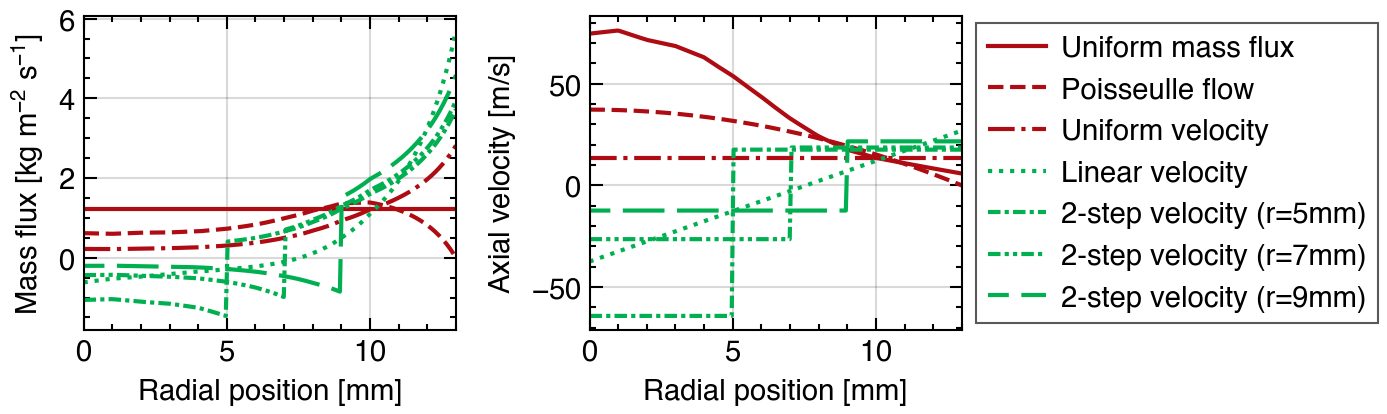

In [15]:
wedme.apply.slide()

if stylename == 'paper': fig, axes = wedme.subplots.paper(1, 2, figsize=(wedme.PAPER_PW, wedme.PAPER_DH*0.7))
if stylename == 'slide': fig, axes = wedme.subplots.slide(1, 2, figsize=(wedme.SLIDE_FW, wedme.SLIDE_TTH))

for i, (name, fitparameter, fitfunction, _) in enumerate(plots):
    if i in idx_skip:
        continue

    success = successes[i]
    color = '#00B050' if success else '#AE0B12'

    axes[0].plot(r_sim, massflux_abs[i, :], linestyle=linestyles_plot[i], color=color, label=name)
    axes[1].plot(r_sim, velocity[i, :], linestyle=linestyles_plot[i], color=color, label=name)

    for ax in axes:
        ax.set_xlim(0, 13)

        # If all data in this axis is >0, set ylim to 0
        maxy = np.nanmax(ax.lines[0].get_ydata())
        miny = np.nanmin(ax.lines[0].get_ydata())
        diffy = max(maxy - miny, abs(maxy), abs(miny))

        ax.set_xlabel("Radial position [mm]")

    axes[0].set_ylabel(r"Mass flux [$\mathrm{kg\ m^{-2}\ s^{-1}}$]")
    axes[1].set_ylabel(r"Axial velocity [$\mathrm{m/s}$]")
    axes[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5), handlelength=2)

fig.savefig(export_path("massflux_velocity"), bbox_inches='tight', dpi=1000)
plt.show()

## Cumulative (low uncertainty) (Fig. 5, 7)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


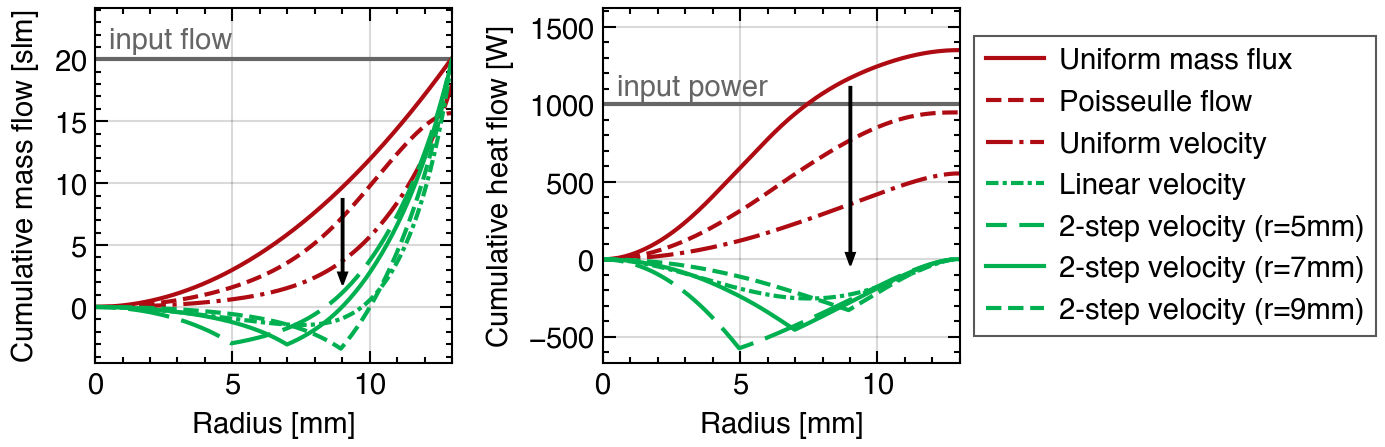

In [16]:
from matplotlib.lines import Line2D

r_arrow = 9 # was 7

if stylename == 'paper': fig, (ax1, ax2) = wedme.subplots.paper(1, 2, width_ratios=[1,1], figsize=(wedme.PAPER_SCW, wedme.PAPER_DH*0.75))
elif stylename == 'slide': fig, (ax1, ax2) = wedme.subplots.slide_fw_tth(1, 2, width_ratios=[1,1])
else: raise ValueError(f"Unknown style '{stylename}'")

ax2.hlines(power, 0, 13, '#666', linestyle='-')
ax2.text(0.5, power*1.02, "input power", color='#666', verticalalignment='bottom')
ax1.hlines(flowrate, 0, 13, '#666', linestyle='-')
ax1.text(0.5, flowrate*1.02, "input flow", color='#666', verticalalignment='bottom')
for i, (name, fitparameter, fitfunction, refit) in enumerate(plots):
    if i in idx_skip: continue
    
    success = successes[i]
    color = '#00B050' if success else '#AE0B12'

    ax1.plot(r_sim, massflow_cum_slm[i, :], linestyle=linestyles[i % len(linestyles)], color=color)
    ax2.plot(r_sim, heatflux_cum[i, :], color=color, linestyle=linestyles[i % len(linestyles)], label=name)


    for ax in [ax1, ax2]:
        ax.set_xlim(0, 13)

        # If all data in this axis is >0, set ylim to 0
        maxy = np.nanmax(ax.lines[0].get_ydata())
        miny = np.nanmin(ax.lines[0].get_ydata())
        diffy = max(maxy - miny, abs(maxy), abs(miny))
        ax.set_xlabel("Radius [mm]")

    ax1.set_ylabel(r"Cumulative mass flow [$\mathrm{slm}$]")
    ax2.set_ylabel(r"Cumulative heat flow [$\mathrm{W}$]")


id_rhalf = np.argmin(np.abs(r_sim - r_arrow))
if np.sum(~successes) != 0 and flowrate != 10:
    flow_max_unsuccessfull = np.max(massflow_cum_slm[~successes, id_rhalf])
    flow_max_successfull = np.max(massflow_cum_slm[successes, id_rhalf])
    heatflow_max_unsuccessfull = np.max(heatflux_cum[~successes, id_rhalf])
    heatflow_max_successfull = np.max(heatflux_cum[successes, id_rhalf])

    wedme.util.arrow(r_sim[id_rhalf], flow_max_unsuccessfull*0.9, 0, (flow_max_successfull-flow_max_unsuccessfull)*0.85, ax=ax1, facecolor='k', width_ratio=0.005, zorder=200, head_width_relative=5)
    wedme.util.arrow(r_sim[id_rhalf], heatflow_max_unsuccessfull*0.95, 0, (heatflow_max_successfull-heatflow_max_unsuccessfull)*0.85, ax=ax2, facecolor='k', width_ratio=0.005, zorder=200, head_width_relative=5)


custom_lines = [Line2D([0], [0], color='#AE0B12'),
                Line2D([0], [0], color='#00B050')]

ax1.set_ylim(top=max(flowrate, np.max(massflow_cum_slm))*1.2)
ax2.set_ylim(top=max(power, np.max(heatflux_cum))*1.2)

ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), handlelength=2)

fig.savefig(export_path("cumulativeflows"), bbox_inches='tight', dpi=1000)
plt.show()